In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)


**DATA CREATION**

In [3]:
features = [

"AI Chatbot",
"Fraud Detection",
"Customer Segmentation",
"Churn Prediction",
"Payment Integration",
"Recommendation Engine",
"Search AI",
"Customer Journey Mapping",
"Anomaly Detection",
"Automation Engine",
"Retention Predictor",
"API Integration",
"Experimentation Platform",
"Process Intelligence",
"Cost Optimizer",
"Customer Risk Score",
"Lead Scoring AI",
"Personalization Engine",
"Voice Assistant",
"Smart Notifications"

]

n = len(features)

data = pd.DataFrame({

'Feature_Name':features,

'Customer_Demand':np.random.randint(40,95,n),

'User_Impact':np.random.randint(30,100,n),

'Revenue_Potential':np.random.randint(20,90,n),

'Strategic_Value':np.random.randint(30,95,n),

'Risk_Score':np.random.randint(10,70,n),

'Dev_Effort':np.random.randint(20,90,n),

'Engineering_Cost':np.random.randint(5000,50000,n),

'Customer_Reach':np.random.randint(1000,100000,n),

'Confidence':np.random.randint(50,95,n),

'Time_to_Build':np.random.randint(2,24,n)

})

# Add realistic relationships (industry style correlations)

data['ROI_Score'] = (
data['Revenue_Potential']*0.5 +
data['Customer_Demand']*0.3 -
data['Engineering_Cost']/2000 +
np.random.normal(0,5,n)
)

data['RICE_Score'] = (

data['Customer_Reach']/1000 *
data['User_Impact'] *
data['Confidence']

)/data['Dev_Effort']

**Calculation**

In [4]:
data['AI_Priority_Score'] = (

data['RICE_Score']*0.35 +

data['ROI_Score']*0.25 +

data['Strategic_Value']*0.20 +

data['Customer_Demand']*0.10 -

data['Risk_Score']*0.05 -

data['Dev_Effort']*0.05

)

# Convert to priority levels

def priority(x):

    if x >= data['AI_Priority_Score'].quantile(.66):
        return "High"

    elif x >= data['AI_Priority_Score'].quantile(.33):
        return "Medium"

    else:
        return "Low"

data['Traditional_Priority'] = data['AI_Priority_Score'].apply(priority)


**MODEL DEPLYOMENT**

In [5]:
ml_data = data.copy()

le = LabelEncoder()

ml_data['Traditional_Priority'] = le.fit_transform(
ml_data['Traditional_Priority']
)

# Important: remove engineered outputs

ml_features = [

'Customer_Demand',
'User_Impact',
'Revenue_Potential',
'Strategic_Value',
'Risk_Score',
'Dev_Effort',
'Engineering_Cost',
'Customer_Reach',
'Confidence',
'Time_to_Build'

]

X = ml_data[ml_features]

y = ml_data['Traditional_Priority']

X_train,X_test,y_train,y_test = train_test_split(

X,
y,
test_size=0.30,
random_state=10

)

model = DecisionTreeClassifier(

max_depth=4,
min_samples_split=4,
random_state=10

)

model.fit(X_train,y_train)

pred = model.predict(X)

data['ML_Priority'] = le.inverse_transform(pred)

# Add probability insight

probs = model.predict_proba(X)

data['ML_Confidence_%'] = probs.max(axis=1)*100
print()

In [6]:
data['Agreement'] = np.where(

data['Traditional_Priority']==data['ML_Priority'],

"Match",

"Different"

)

data['Priority_Diff'] = (

data['Traditional_Priority']+"-> "+data['ML_Priority']

)

In [7]:
data.head()

,Feature_Name,Customer_Demand,User_Impact,Revenue_Potential,Strategic_Value,Risk_Score,Dev_Effort,Engineering_Cost,Customer_Reach,Confidence,Time_to_Build,ROI_Score,RICE_Score,AI_Priority_Score,Traditional_Priority,ML_Priority,ML_Confidence_%,Agreement,Priority_Diff
0,AI Chatbot,78,31,74,79,34,27,22412,44585,76,8,48.122378,3890.454074,1394.239520,Medium,Medium,100.0,Match,Medium-> Medium
1,Fraud Detection,91,59,83,33,69,54,38270,65044,62,3,46.219029,4406.128741,1563.249816,High,High,100.0,Match,High-> High
2,Customer Segmentation,68,67,22,31,69,54,11910,43557,90,4,29.084166,4863.865000,1716.473791,High,High,100.0,Match,High-> High
3,Churn Prediction,54,31,70,35,69,52,30446,50080,52,18,32.881653,1552.480000,557.938413,Low,High,100.0,Different,Low-> High
4,Payment Integration,82,93,26,83,54,24,5206,3693,88,6,36.777799,1259.313000,470.854000,Low,Low,100.0,Match,Low-> Low


**VISUALIZATION**

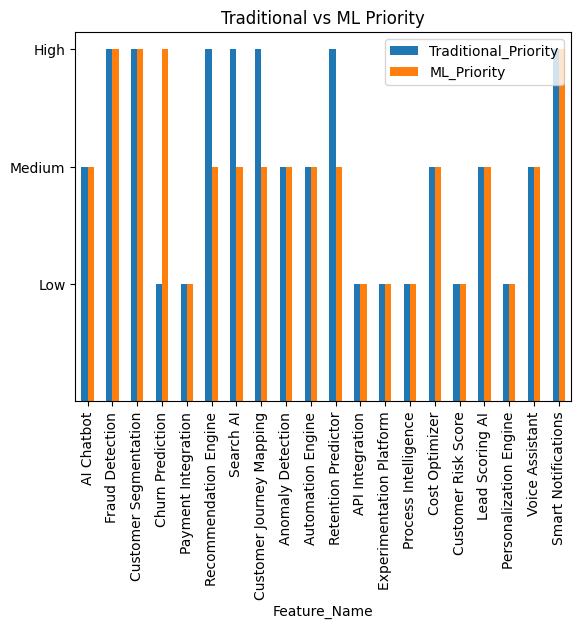

In [8]:
import matplotlib.pyplot as plt

priority_map = {'Low':1,'Medium':2,'High':3}

data['Traditional_Priority'] = data['Traditional_Priority'].map(priority_map)
data['ML_Priority'] = data['ML_Priority'].map(priority_map)

data.set_index('Feature_Name')[['Traditional_Priority','ML_Priority']].plot(kind='bar')

plt.yticks([1,2,3],['Low','Medium','High'])
plt.title("Traditional vs ML Priority")
plt.show()

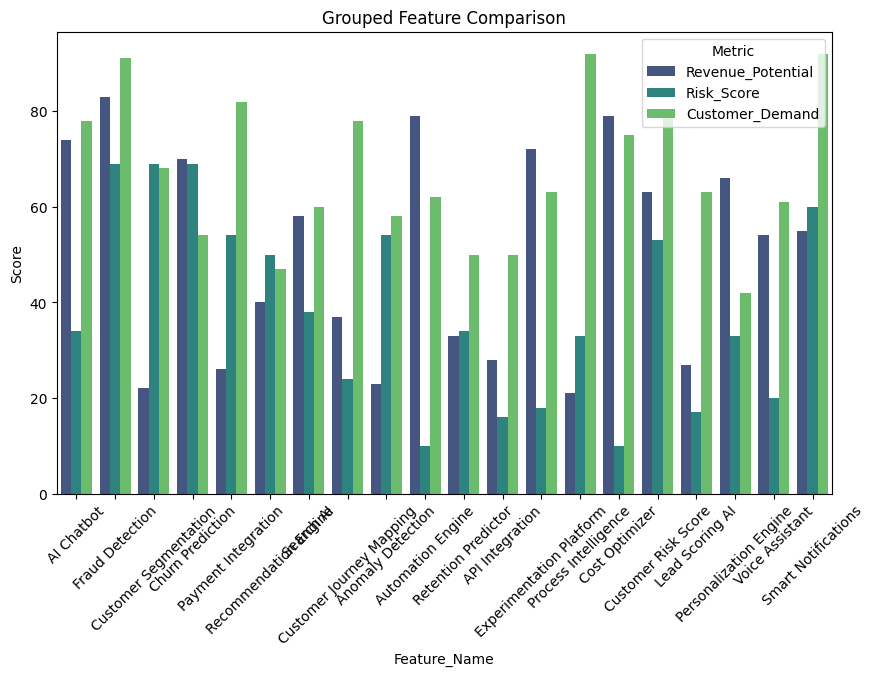

In [9]:
import seaborn as sns

data_melted = data.melt(

id_vars="Feature_Name",

value_vars=['Revenue_Potential','Risk_Score','Customer_Demand'],

var_name="Metric",

value_name="Score"

)

plt.figure(figsize=(10,6))

sns.barplot(

data=data_melted,

x="Feature_Name",

y="Score",

hue="Metric",

palette="viridis"

)

plt.xticks(rotation=45)

plt.title("Grouped Feature Comparison")

plt.show()

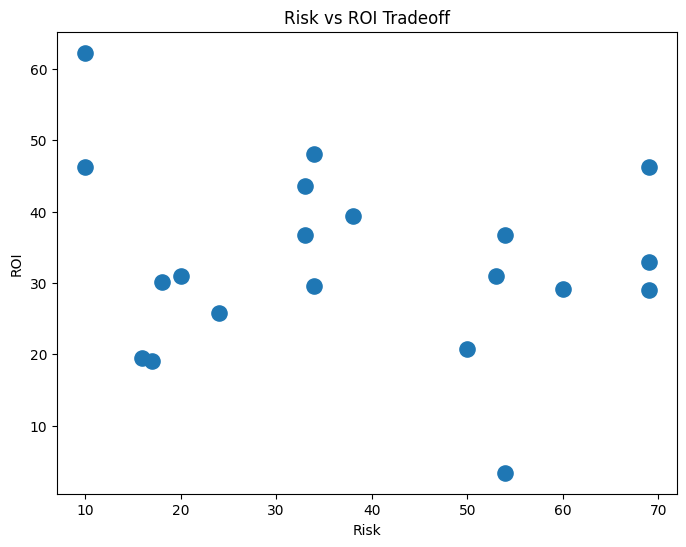

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(

data['Risk_Score'],
data['ROI_Score'],
s=120

)

plt.xlabel("Risk")

plt.ylabel("ROI")

plt.title("Risk vs ROI Tradeoff")

plt.show()

/tmp/ipykernel_380/35219095.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


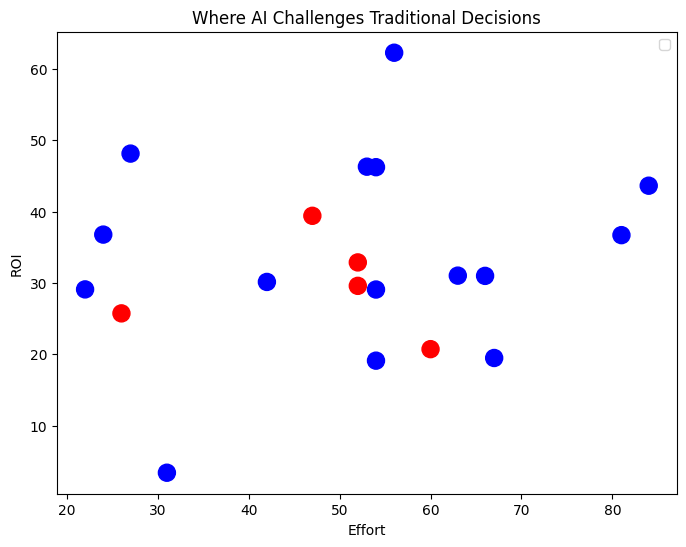

In [11]:
colors = data['Agreement'].map({
'Match':'blue',
'Different':'red'
})

plt.figure(figsize=(8,6))

plt.scatter(

data['Dev_Effort'],
data['ROI_Score'],
c=colors,
s=150

)

plt.title("Where AI Challenges Traditional Decisions")

plt.xlabel("Effort")

plt.ylabel("ROI")
plt.legend()

plt.show()

<BarContainer object of 5 artists>

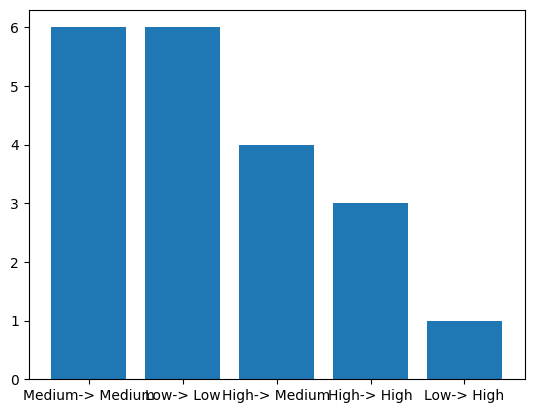

In [12]:
plt.bar(data['Priority_Diff'].value_counts().index,data['Priority_Diff'].value_counts())

Compare ML prioritization vs PM decision success rate.

In [13]:
match_percentage = (data['Agreement'] == 'Match').mean() * 100
print(f"Agreement Rate (ML Priority vs Traditional Priority): {match_percentage:.2f}%")


Agreement Rate (ML Priority vs Traditional Priority): 75.00%
